# Exercise: Recommendation System Optimization
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Apply RL to recommendation systems
- Optimize user engagement
- Balance exploration and exploitation
- Apply to e-commerce

## Real-World Context

Optimize product recommendations to maximize user engagement.

**Task**: Build RL-based recommendation system.

---

## Task 1: Recommendation Environment (30 points)

Create recommendation environment:
1. Define user preferences
2. Define products
3. Define reward function

## Exercise Brief

This exercise checks whether students can apply RL thinking to an application scenario, not only to a textbook algorithm.

They should identify states, actions, rewards, risks, and trade-offs in a realistic decision problem.

Why this matters: Unit 5 is about transfer of understanding from theory to applications.

This exercise verifies that students can reason about that transfer clearly.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Exercise Goal

This exercise asks you to formulate an application problem, define the RL pieces,
and reason about the trade-offs rather than jumping straight to a large training system.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Recommendation policy: what to show the user.
- Feedback signal: clicks or other user response.
- Long-term engagement: more than one-step reward.
- Preference uncertainty: not knowing the user fully yet.

### Quick Check
- Why can recommendation be an RL problem?
- What goes wrong if we optimize only immediate clicks?
- Where are states, actions, and rewards here?

### Common Mistakes
- Reducing recommendation to one-step prediction.
- Using the wrong reward proxy.
- Ignoring exploration of user preferences.


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np


# Class `RecommendationEnv` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class RecommendationEnv:
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, user_preferences, product_vectors.
    def __init__(self, user_preferences, product_vectors):
        # Save a value in a name so the next lines can read it.
        self.user_preferences = np.asarray(user_preferences, dtype=float)
        # Another assignment—same idea: store a value for the lines below.
        self.product_vectors = np.asarray(product_vectors, dtype=float)
        # Another assignment—same idea: store a value for the lines below.
        self.n_products = len(product_vectors)
        # Another assignment—same idea: store a value for the lines below.
        self.current_user = 0

    # Function `reset` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, user_id.
    def reset(self, user_id=0):
        # Save a value in a name so the next lines can read it.
        self.current_user = user_id
        # Send a value back to whoever called this function.
        return self.user_preferences[user_id]

    # Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, action.
    def step(self, action):
        # Save a value in a name so the next lines can read it.
        user_vector = self.user_preferences[self.current_user]
        # Another assignment—same idea: store a value for the lines below.
        product_vector = self.product_vectors[action]
        # Unpack the one-step model output from transition(state, action).
        reward = float(np.dot(user_vector, product_vector))
        # Save a value in a name so the next lines can read it.
        done = True
        # Another assignment—same idea: store a value for the lines below.
        info = {"user_id": self.current_user}
        # Send a value back to whoever called this function.
        return user_vector, reward, done, info


# Save a value in a name so the next lines can read it.
user_preferences = [
    # Execute: [0.9, 0.1, 0.0],
    [0.9, 0.1, 0.0],
    # Execute: [0.1, 0.8, 0.2],
    [0.1, 0.8, 0.2],
    # Execute: [0.2, 0.2, 0.9],
    [0.2, 0.2, 0.9],
# Execute: ]
]
# Save a value in a name so the next lines can read it.
product_vectors = [
    # Execute: [1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    # Execute: [0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0],
    # Execute: [0.0, 0.0, 1.0],
    [0.0, 0.0, 1.0],
    # Execute: [0.6, 0.3, 0.1],
    [0.6, 0.3, 0.1],
# Execute: ]
]

# Save a value in a name so the next lines can read it.
env = RecommendationEnv(user_preferences, product_vectors)
# Create or choose a variable used in the Bellman warm-up demo.
state = env.reset(user_id=1)
# Show text or numbers in the cell output area under the code.
print("Sample user state:", state)
# Show text or numbers in the cell output area under the code.
print("Reward for recommending product 1:", env.step(1)[1])


Sample user state: [0.1 0.8 0.2]
Reward for recommending product 1: 0.8


## Task 2: RL Agent (35 points)

Implement an RL-style decision component appropriate to your chosen setup:
1. A policy, scoring rule, or value estimate
2. A clear action-selection rule
3. An evaluation loop that shows how the agent behaves

You do **not** need a full deep-learning training stack unless your instructor explicitly asks for one.

### Step Guide

**What this cell does:** Summarize or compare results (policies, returns, tables) for the lesson goal.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Tables, arrays, or comparison prints showing which policy or method wins.

**If you feel lost:** If output is empty, run the previous cells that define the data this cell consumes.


In [2]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Task 2: simple value-based recommendation baseline

# Function `recommend_greedily` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: env, user_id.
def recommend_greedily(env, user_id):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = env.reset(user_id=user_id)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for action in range(env.n_products):
        # Save a value in a name so the next lines can read it.
        _, reward, _, _ = env.step(action)
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
    # Save a value in a name so the next lines can read it.
    best_action = int(np.argmax(rewards))
    # Send a value back to whoever called this function.
    return best_action, rewards


# Start a loop: repeat the indented block once per item in the sequence.
for user_id in range(len(user_preferences)):
    # Save a value in a name so the next lines can read it.
    best_action, rewards = recommend_greedily(env, user_id)
    # Show text or numbers in the cell output area under the code.
    print(f"User {user_id}: rewards={np.round(rewards, 2)} -> best product={best_action}")

# Show text or numbers in the cell output area under the code.
print("\nReflection:")
# Show text or numbers in the cell output area under the code.
print("- In a real RL system, rewards would come over time, not from a direct dot product.")
# Show text or numbers in the cell output area under the code.
print("- This baseline still helps you define states, actions, and rewards clearly.")


User 0: rewards=[0.9  0.1  0.   0.57] -> best product=0
User 1: rewards=[0.1  0.8  0.2  0.32] -> best product=1
User 2: rewards=[0.2  0.2  0.9  0.27] -> best product=2

Reflection:
- In a real RL system, rewards would come over time, not from a direct dot product.
- This baseline still helps you define states, actions, and rewards clearly.


## Task 3: Real-World Application (35 points)

Write short answers for the following:

1. What is the **state** in your recommendation problem?
2. What is the **action**?
3. What is the **reward**, and what user behavior does it represent?
4. What exploration risk exists in this setting?
5. Name one ethical issue such as manipulation, filter bubbles, or unfair exposure.

**Submission**: complete notebook with code and written reasoning.

**Grading**: 100 points total

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


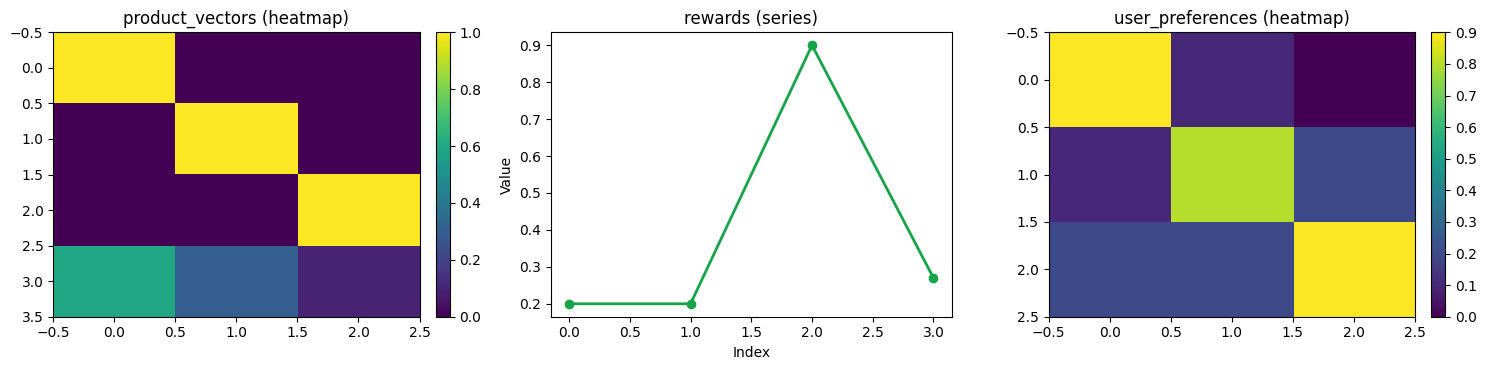

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can choose and explain RL ideas in realistic application settings, not only in textbook examples.

**If students remember one idea:** The strongest sign of understanding is being able to justify why a method fits a task, what assumptions it needs, and what risks it carries.

**Quick check before moving on:**
- Can you explain why your chosen RL framing suits the application you discussed?
- Can you describe what challenge or limitation would matter most in a real deployment?

**Bridge to the next step:** After this exercise, students should be ready to integrate the whole course in the final project and assessment work.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=14 | term=True | trunc=False


objc[14626]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111ce0138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1121dc9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14626]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111ce0188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1121dca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14626]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111cdfc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1121dca68). T

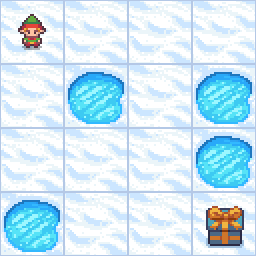

In [4]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
